<a href="https://colab.research.google.com/github/isra-data-analytics/isra-data-analytics/blob/main/Taller_de_EDA_Apartamentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import pandas as pd
import requests

# 1. DEFINICIÓN DE ESTRUCTURA Y RUTAS
carpetas = ['input', 'source', 'output']
for folder in carpetas:
    os.makedirs(folder, exist_ok=True)
    print(f" Carpeta '{folder}' lista.")

# 2. DESCARGA AUTOMÁTICA DESDE GITHUB
# Usamos la URL 'raw' para obtener el archivo real, no la página web
base_url = "https://raw.githubusercontent.com/isra-data-analytics/isra-data-analytics/main/"

archivos = {
    "Variables Categoricas.xlsx": "input/Variables Categoricas.xlsx",
    "Variables Numericas.xlsx": "input/Variables Numericas.xlsx",
    "apartamentos_bogota (1).xlsx": "input/apartamentos_bogota (1).xlsx"
}

print("\n Descargando datasets desde GitHub...")
for nombre_web, ruta_local in archivos.items():
    # El nombre en la URL debe tener %20 en lugar de espacios
    url_final = base_url + nombre_web.replace(" ", "%20")
    response = requests.get(url_final)

    if response.status_code == 200:
        with open(ruta_local, 'wb') as f:
            f.write(response.content)
        print(f" {nombre_web} guardado en {ruta_local}")
    else:
        print(f" Error al descargar {nombre_web} (Status: {response.status_code})")

# 3. CARGA DE DATOS PARA TU MODELO
try:
    datos_CAT = pd.read_excel('input/Variables Categoricas.xlsx')
    print("\n DATOS CARGADOS: El modelo ya tiene la información vinculada.")
except Exception as e:
    print(f" Error al cargar los datos: {e}")

# Así el archivo caerá siempre en la carpeta que creamos
ruta_salida = os.path.join('output', 'tablas_frecuencia.xlsx')



 Carpeta 'input' lista.
 Carpeta 'source' lista.
 Carpeta 'output' lista.

 Descargando datasets desde GitHub...
 Variables Categoricas.xlsx guardado en input/Variables Categoricas.xlsx
 Variables Numericas.xlsx guardado en input/Variables Numericas.xlsx
 apartamentos_bogota (1).xlsx guardado en input/apartamentos_bogota (1).xlsx

 DATOS CARGADOS: El modelo ya tiene la información vinculada.


In [6]:
# =============================================================================
# LIBRERÍAS NECESARIAS
# =============================================================================

# Tratamiento de datos
# -----------------------------------------------------------------------------
import numpy as np          # Manejo de arrays y operaciones numéricas eficientes
import pandas as pd         # Manipulación y análisis de datos estructurados
from tabulate import tabulate   # Formateo de tablas para mejor visualización
from scipy import stats

# Gráficos
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt         # Librería base para visualizaciones
from matplotlib import style           # Estilos para gráficos
import matplotlib.ticker as ticker     # Formateo de ejes en gráficos
import seaborn as sns                 # Visualizaciones estadísticas avanzadas
import statsmodels.api as sm          # Modelos estadísticos y econométricos

# Configuración matplotlib
# -----------------------------------------------------------------------------
plt.rcParams['image.cmap'] = "bwr"    # Configura el mapa de colores predeterminado
plt.rcParams['savefig.bbox'] = "tight"  # Ajusta los márgenes al guardar figuras
style.use('ggplot') or plt.style.use('ggplot')  # Establece estilo visual ggplot

# Configuración warnings
# -----------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')  # Desactiva mensajes de advertencia
# pd.options.display.float_format = '{:.2f}'.format # Suprimir notación cientifica en python

In [7]:

pip install stats

## Lectura de tablas

In [15]:
# 1. Cargar el dataset maestro (el que tiene todo)
dataset_maestro = pd.read_excel('input/apartamentos_bogota (1).xlsx')

# 2. Cargar selección de numéricas
variables_numericas = pd.read_excel('input/Variables Numericas.xlsx')

# 3. Cargar selección de categóricas
variables_categoricas = pd.read_excel('input/Variables Categoricas.xlsx')


In [16]:
variables_categoricas.head()

,tipo_propiedad,localidad,sector,barrio,estrato,antiguedad,tipo_operacion
0,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,3,ENTRE 10 Y 20 ANOS,VENTA
1,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,3,MAS DE 20 ANOS,VENTA
2,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,3,ENTRE 0 Y 5 ANOS,VENTA
3,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,2,ENTRE 10 Y 20 ANOS,VENTA
4,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,3,MAS DE 20 ANOS,VENTA


In [17]:
variables_numericas.head()

,area,habitaciones,banos,parqueaderos,estrato
0,76.0,3,2,1,3
1,63.0,3,2,0,3
2,54.0,3,2,0,3
3,43.0,2,2,0,2
4,48.0,3,2,0,3


In [18]:

print("\n ENCABEZADOS: VARIABLES NUMÉRICAS")
display(df_num.head())

print("\n ENCABEZADOS: VARIABLES CATEGÓRICAS")
display(df_cat.head())


 ENCABEZADOS: VARIABLES NUMÉRICAS


,area,habitaciones,banos,parqueaderos,estrato
0,76.0,3,2,1,3
1,63.0,3,2,0,3
2,54.0,3,2,0,3
3,43.0,2,2,0,2
4,48.0,3,2,0,3



 ENCABEZADOS: VARIABLES CATEGÓRICAS


,tipo_propiedad,localidad,sector,barrio,estrato,antiguedad,tipo_operacion
0,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,3,ENTRE 10 Y 20 ANOS,VENTA
1,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,3,MAS DE 20 ANOS,VENTA
2,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,3,ENTRE 0 Y 5 ANOS,VENTA
3,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,2,ENTRE 10 Y 20 ANOS,VENTA
4,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,3,MAS DE 20 ANOS,VENTA


In [19]:
# Combinar los DataFrames
df = pd.concat([variables_numericas, variables_categoricas], axis=1)
df.head()

,area,habitaciones,banos,parqueaderos,estrato,tipo_propiedad,localidad,sector,barrio,estrato,antiguedad,tipo_operacion
0,76.0,3,2,1,3,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,3,ENTRE 10 Y 20 ANOS,VENTA
1,63.0,3,2,0,3,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,3,MAS DE 20 ANOS,VENTA
2,54.0,3,2,0,3,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,3,ENTRE 0 Y 5 ANOS,VENTA
3,43.0,2,2,0,2,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,2,ENTRE 10 Y 20 ANOS,VENTA
4,48.0,3,2,0,3,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,3,MAS DE 20 ANOS,VENTA


In [20]:
print(variables_categoricas.shape)
print(variables_numericas.shape)

(43013, 7)
(43013, 5)


## Entendimiento de los Datos


In [23]:
# Estructura y Tipos de Datos
dataset_maestro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43013 entries, 0 to 43012
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   _id                      43013 non-null  object        
 1   codigo                   43013 non-null  object        
 2   tipo_propiedad           43013 non-null  object        
 3   tipo_operacion           43013 non-null  object        
 4   precio_venta             27584 non-null  float64       
 5   area                     43013 non-null  float64       
 6   habitaciones             43013 non-null  object        
 7   banos                    43013 non-null  object        
 8   administracion           43013 non-null  object        
 9   parqueaderos             43013 non-null  object        
 10  sector                   43013 non-null  object        
 11  estrato                  43013 non-null  object        
 12  antiguedad               43013 n

In [22]:
print(f"El dataset tiene {dataset_maestro.shape[0]} registros y {dataset_maestro.shape[1]} columnas.")

El dataset tiene 43013 registros y 46 columnas.


In [28]:
#ME MUESTRA LOS NOMBRES DE LAS VARIABLES Y EL TIPO (int64, float64 u object)

print(dataset_maestro.dtypes)

_id                                object
codigo                             object
tipo_propiedad                     object
tipo_operacion                     object
precio_venta                      float64
area                              float64
habitaciones                       object
banos                              object
administracion                     object
parqueaderos                       object
sector                             object
estrato                            object
antiguedad                         object
latitud                           float64
longitud                          float64
direccion                          object
descripcion                        object
website                            object
last_view                          object
datetime                   datetime64[ns]
url                                object
timeline                           object
estado                             object
compañia                          

In [29]:
print(dataset_maestro.dtypes.value_counts())

object            35
float64            7
int64              2
datetime64[ns]     1
bool               1
Name: count, dtype: int64


In [26]:
#Análisis de Valores Nulos

# Cálculo de nulos y su porcentaje
nulos = dataset_maestro.isnull().sum()
porcentaje_nulos = (nulos / len(dataset_maestro)) * 100

# Tabla de diagnóstico
tabla_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
display(tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values(by='Nulos', ascending=False))

,Nulos,Porcentaje (%)
precio_arriendo,27184,63.20
precio_venta,15429,35.87
datetime,2,0.00


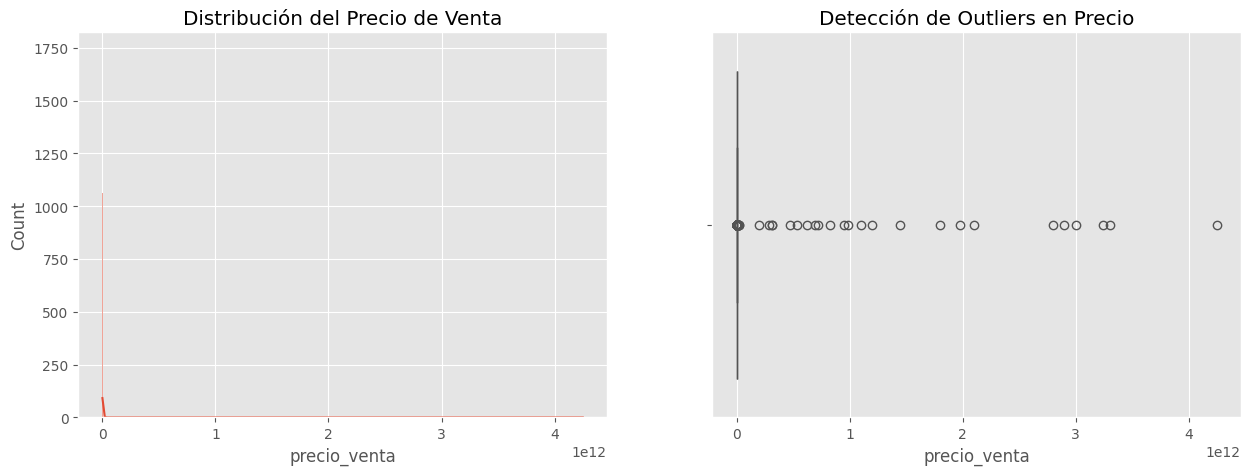

In [30]:
#Distribución del Precio y Outliers


# Histograma y Boxplot
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dataset_maestro['precio_venta'], kde=True, ax=ax[0])
ax[0].set_title('Distribución del Precio de Venta')

sns.boxplot(x=dataset_maestro['precio_venta'], ax=ax[1])
ax[1].set_title('Detección de Outliers en Precio')

plt.show()

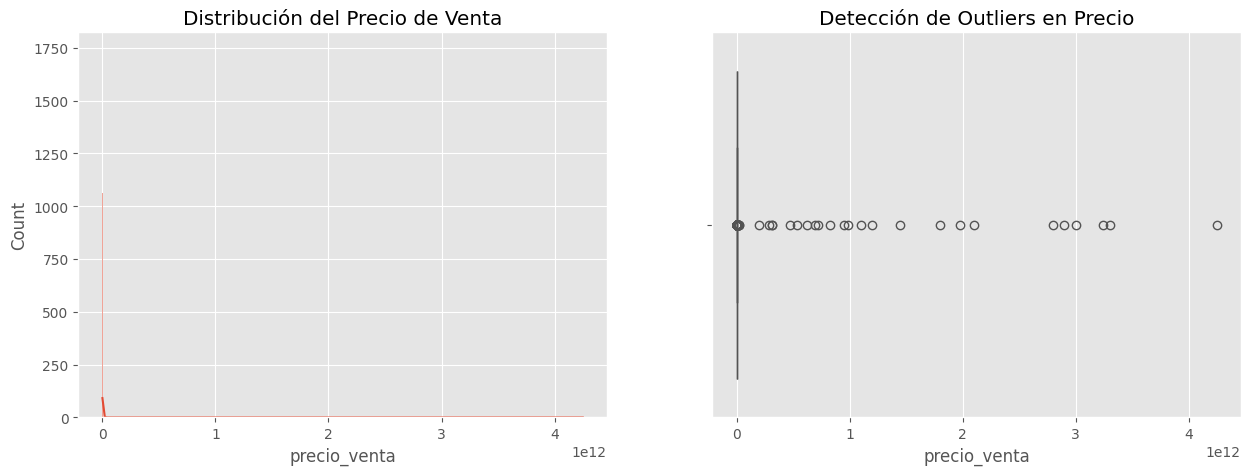

In [31]:
# Distribución del Precio y Outliers

# Histograma y Boxplot
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dataset_maestro['precio_venta'], kde=True, ax=ax[0])
ax[0].set_title('Distribución del Precio de Venta')

sns.boxplot(x=dataset_maestro['precio_venta'], ax=ax[1])
ax[1].set_title('Detección de Outliers en Precio')

plt.show()

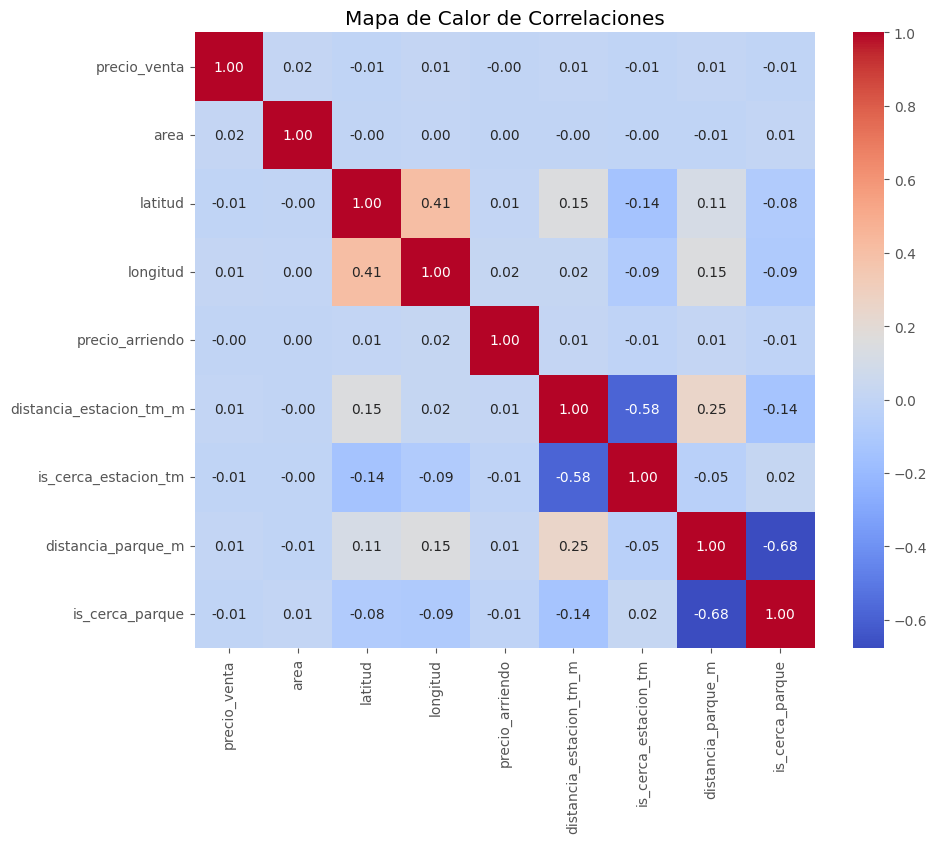

In [32]:
# Relaciones y Correlaciones

# Matriz de correlación
plt.figure(figsize=(10, 8))
# Seleccionamos solo las numéricas para la matriz
corr = dataset_maestro.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones')
plt.show()

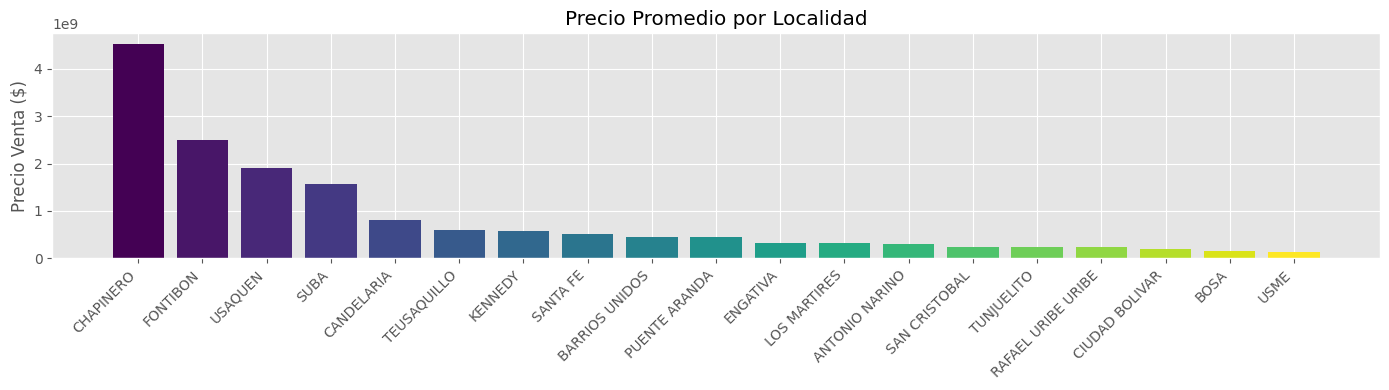

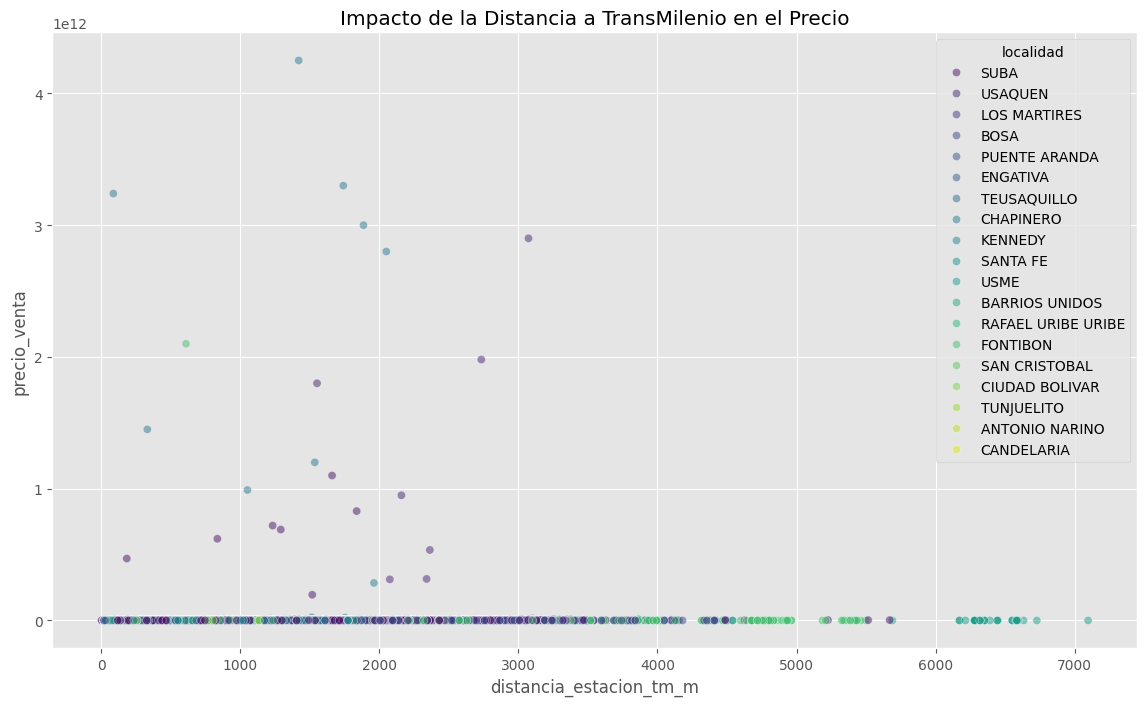

In [52]:
# Localidad y Factores Externos (Parques/TransMilenio)

# Precio promedio por localidad
plt.figure(figsize=(14, 4))
data = dataset_maestro.groupby('localidad')['precio_venta'].mean().sort_values(ascending=False)
colors = plt.cm.viridis(np.linspace(0, 1, len(data))) # Generar colores diferentes para cada barra

# Crear gráfico de barras
plt.bar(data.index, data.values, color=colors)

plt.title('Precio Promedio por Localidad')
plt.ylabel('Precio Venta ($)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


# Relación Distancia vs Precio
plt.figure(figsize=(14, 8))
scatter = sns.scatterplot(data=dataset_maestro, x='distancia_estacion_tm_m', y='precio_venta',
                          alpha=0.5, hue=dataset_maestro['localidad'],
                          palette='viridis', legend='full')


plt.title('Impacto de la Distancia a TransMilenio en el Precio')
plt.show()


In [34]:
# Criterio de "Cerca" o "Lejos"

# Definición estadística de cercanía
distancias = dataset_maestro[['distancia_parque_m', 'distancia_estacion_tm_m']].describe()
display(distancias)

,distancia_parque_m,distancia_estacion_tm_m
count,43013.000000,43013.000000
mean,808.884766,1270.515946
std,447.796211,841.814012
min,0.220000,4.940000
25%,470.140000,578.380000
50%,750.140000,1175.520000
75%,1087.730000,1707.920000
max,6276.510000,7095.660000


In [54]:
# Limpiar y convertir la columna de administración a numérica (sin eliminar datos originales)
dataset_maestro['administracion_limpia'] = pd.to_numeric(dataset_maestro['administracion'], errors='coerce')

# Calcular correlación solo con los valores válidos (ignorando NaNs automáticamente)
correlacion_admin = dataset_maestro['precio_venta'].corr(dataset_maestro['administracion_limpia'])
print(f"La correlación entre Precio y Administración es de: {correlacion_admin:.2f}")

# Mostrar cuántos valores se usaron
valores_validos = dataset_maestro['administracion_limpia'].notna().sum()
print(f"Valores válidos considerados: {valores_validos} de {len(dataset_maestro)} totales")

La correlación entre Precio y Administración es de: 0.03
Valores válidos considerados: 35088 de 43013 totales


## Preparación de los Datos